### Get the data

the images we're working with are from the Food101 daataset
(101 different classes of food):
https://www.kaggle.com/dansbecker/food-101.

However we've modifiednit to only use two classes(pizza & steak) using the image data modification notebook:


Computer vision is the practice of writing algorithms which can discover patterns in visual data. Such as the camera of a self-driving car recognizing the car in front.

https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

> We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesnt work ) before scalling up.

In [ ]:
 ## Get the data
 import zipfile

 !wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# !wget, using we can download the file in google collab

 #unzip the downloaded file

 zip_ref = zipfile.ZipFile("pizza_steak.zip")
 zip_ref.extractall()
 zip_ref.close()

--2025-07-18 17:57:08--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.253.118.207, 172.217.194.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  22.2MB/s    in 5.9s    

2025-07-18 17:57:15 (17.7 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



A very  crucial step at the begining of any machine learning project is becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [ ]:
## Inspect the data (become one with it)

!ls pizza_steak  # !ls lists the files in the tensor

test  train


In [ ]:
!ls pizza_steak/train/

pizza  steak


In [ ]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
# os is operating system  to navigate your computer’s file system
import os

# walk through pizza/_steak directory and list number of files
for dirpath, dirnames , filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.


In [ ]:
!ls pizza_steak

test  train


In [ ]:
# -l (long format) shows detailed info like permissions, owner, size, and modification date.
#a includes hidden files (those starting with a dot .).

!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Jul 18 17:57 .
drwxr-xr-x 1 root root 4096 Jul 18 17:57 ..
drwxr-xr-x 4 root root 4096 Jul 18 17:57 test
drwxr-xr-x 4 root root 4096 Jul 18 17:57 train


### There is no extra file in our pizza_steak director

In [ ]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

# lenth of the list of directories in pizz_steak , train file's steak
num_steak_images_train

750

To visualize our images , first let's get the class names programmatically

In [ ]:
# Get the classnames programmatically
# pathlib = modern way of handling file paths in Python! , this module provides an object-oriented interface for working with filesystem paths. Instead of juggling strings and os.path functions, you use Path objects that behave like real-world paths.

import pathlib
import numpy as np
data_dir =pathlib.Path("pizza_steak/train")

# To create a list of class_name from the subdirectory
class_names= np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [ ]:
# Lets visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class ):
  # setup the target directory (we'll view images from here )
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder),1)
  print(random_image)

  # randomly sample 1 item in the list of directory of target_folder

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)   # imshow is imageshow
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}")

  return img


['618348.jpg']
Image shape: (512, 512, 3)


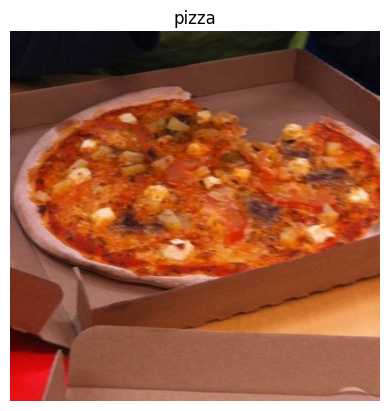

In [ ]:
# View a random image from the training dataset

img = view_random_image(target_dir = "pizza_steak/train/",
                        target_class = "pizza")

In [ ]:
# The images awe'he importes and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)


<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 17,  17,  27],
        [ 16,  16,  26],
        [ 15,  15,  25],
        ...,
        [ 13,  12,  18],
        [ 14,  13,  19],
        [ 15,  14,  20]],

       [[ 17,  17,  27],
        [ 16,  16,  26],
        [ 16,  16,  26],
        ...,
        [ 14,  13,  19],
        [ 16,  15,  21],
        [ 18,  17,  23]],

       [[ 17,  17,  27],
        [ 16,  16,  26],
        [ 16,  16,  26],
        ...,
        [ 15,  14,  20],
        [ 16,  15,  21],
        [ 17,  16,  22]],

       ...,

       [[232,  16,  19],
        [234,  18,  21],
        [235,  19,  22],
        ...,
        [197, 138, 124],
        [196, 137, 123],
        [194, 135, 121]],

       [[231,  15,  18],
        [233,  17,  20],
        [235,  19,  22],
        ...,
        [199, 141, 127],
        [199, 140, 126],
        [195, 136, 122]],

       [[232,  16,  19],
        [232,  16,  19],
        [234,  18,  21],
        ...,
        [200, 142, 12

### Preprocessing

In [ ]:
# View the image shape
img.shape
# returns  width , height , colour channels

(512, 512, 3)

Most images are stored with pixel values ranging from 0 to 255—these are 8-bit unsigned integers. But many machine learning models (especially neural networks) work better when input values are normalized to a smaller, consistent range—typically 0 to 1.
so you write img/255


In [ ]:
# Getting all the pixel values between 0 & 1
img/255.

array([[[0.06666667, 0.06666667, 0.10588235],
        [0.0627451 , 0.0627451 , 0.10196078],
        [0.05882353, 0.05882353, 0.09803922],
        ...,
        [0.05098039, 0.04705882, 0.07058824],
        [0.05490196, 0.05098039, 0.0745098 ],
        [0.05882353, 0.05490196, 0.07843137]],

       [[0.06666667, 0.06666667, 0.10588235],
        [0.0627451 , 0.0627451 , 0.10196078],
        [0.0627451 , 0.0627451 , 0.10196078],
        ...,
        [0.05490196, 0.05098039, 0.0745098 ],
        [0.0627451 , 0.05882353, 0.08235294],
        [0.07058824, 0.06666667, 0.09019608]],

       [[0.06666667, 0.06666667, 0.10588235],
        [0.0627451 , 0.0627451 , 0.10196078],
        [0.0627451 , 0.0627451 , 0.10196078],
        ...,
        [0.05882353, 0.05490196, 0.07843137],
        [0.0627451 , 0.05882353, 0.08235294],
        [0.06666667, 0.0627451 , 0.08627451]],

       ...,

       [[0.90980392, 0.0627451 , 0.0745098 ],
        [0.91764706, 0.07058824, 0.08235294],
        [0.92156863, 0

Architecture of CNN
1. Input layer
2. Convolution layer
3. Hidden activation
4. Pooling Layer
5. Fully Connected layer
6. Output layer
7. output activation

## An end-to-end example

Let's build a convolutional neural network to find patterns in our images,more specifically we a need way to:


* load our images
* Preprocess our images
* build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the p[ixel between 0 & 1 it is called standardization or normalization])
train_datagen = ImageDataGenerator(rescale =1./255)
valid_datagen = ImageDataGenerator(rescale = 1./255) # test data

#  Set up paths for data directories
train_dir ="/content/pizza_steak/train"
test_dir= "pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory =train_dir,
                                               batch_size = 32,
                                               target_size = (224, 224),
                                               class_mode = "binary",
                                               seed = 42)
valid_data = valid_datagen.flow_from_directory(directory =test_dir,
                                               batch_size = 32,
                                               target_size =(224, 224),
                                               class_mode ="binary",
                                               seed =42)


# Build a CNN model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit our model
history_1 = model_1.fit(train_data, epochs =5,
                      steps_per_epoch =len(train_data),
                      validation_data = valid_data,
                      validation_steps = len(valid_data)
                      )

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step - accuracy: 0.6704 - loss: 0.6087 - val_accuracy: 0.7900 - val_loss: 0.4570
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.7745 - loss: 0.5117 - val_accuracy: 0.8380 - val_loss: 0.3769
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.8082 - loss: 0.4420 - val_accuracy: 0.8020 - val_loss: 0.4243
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.8218 - loss: 0.4116 - val_accuracy: 0.8360 - val_loss: 0.3786
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8333 - loss: 0.4093 - val_accuracy: 0.8680 - val_loss: 0.3523


In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [ ]:
len(train_data)
# 1500 images belong to 2 classes and each batch has 32
# that means there are 1500 images in train set of pizza and steak combined
# and there are 500 images combined in test class of pizza and steak

47

In [ ]:
1500/32
# that is around 47

46.875

> If the above cell is taking longer than 10s per epoch , make sure you're using GPU by going to runtime and change runtime

In [ ]:
 model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

## Using the same model as before

let's replicate the model: we've built in a previous section to see if it works for our image data

The model: we've building is from the TensorFlow playground


In [ ]:
## Set the random seed
tf.random.set_seed(42)

# Create a model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape =(224, 224 ,3)),
    tf.keras.layers.Dense(4, activation ="relu"),
    tf.keras.layers.Dense(4, activation ="relu"),
    tf.keras.layers.Dense(1, activation ="relu")
])

# Compile the mdel
model_2.compile(loss ="binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics= ["accuracy"])

# Fit the model
histroy_2 = model_2.fit(train_data,
                        epochs =5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.5112 - loss: 7.6492 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.5170 - loss: 7.7857 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.5030 - loss: 8.0100 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.4964 - loss: 8.1172 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.5076 - loss: 7.9370 - val_accuracy: 0.5000 - val_loss: 8.0590


Isnt quite working with image data , it shows around 50% accuracy but  using CNN we had around 90% acuuracy

In [ ]:
# Get a summary of modle_2
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

In [ ]:
# improve our model
# adding more nuerons and adding a new layer

# set random seed
tf.random.set_seed(42)

# Creatte model
model_3= tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3)),
    tf.keras.layers.Dense(100 , activation= "relu"),
    tf.keras.layers.Dense(100,activation= "relu"),
    tf.keras.layers.Dense(100 , activation="relu"),
    tf.keras.layers.Dense(1 , activation ="sigmoid")
])

# Compile
model_3.compile(loss ="binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics= ["accuracy"]
)

# Fit the model
histroy_3 = model_3.fit(train_data,
                        epochs =5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.5666 - loss: 3.6215 - val_accuracy: 0.7420 - val_loss: 0.7304
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.7221 - loss: 0.8082 - val_accuracy: 0.7460 - val_loss: 0.6671
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.7725 - loss: 0.5584 - val_accuracy: 0.7760 - val_loss: 0.4881
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.7711 - loss: 0.5330 - val_accuracy: 0.7560 - val_loss: 0.5146
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.7171 - loss: 0.6192 - val_accuracy: 0.7840 - val_loss: 0.4673


After improving the model the accuracy has increased from 50%

In [ ]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

## Binary Classification: Lets break it down

1. become one with the data (visualize, visualize, visualize)

2. Preporcess the data(prepared it our model , the main step here was scaling/normalizing)
3. Created a model
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model(try to beat our baseline)
7. Repeat until statisfied

## 1. Become one with data

['2890573.jpg']
Image shape: (512, 512, 3)
['3644733.jpg']
Image shape: (512, 512, 3)


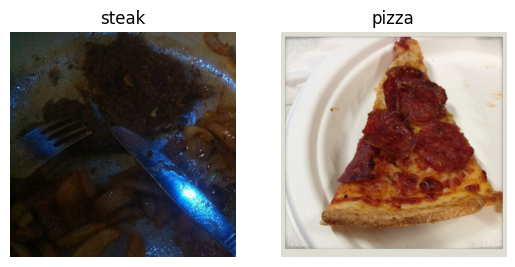

In [ ]:
# Visualize data
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/" , "steak")
plt.subplot(1, 2, 2)
pizza_image =view_random_image("pizza_steak/train/" ,"pizza")



### Preprocess the data (prepare it for  a model)

In [ ]:
# Define directory dataset paths
train_dir ="pizza_steak/train/"
test_dir ="pizza_steak/test/"


## Our next step is turn our data into **batches**
Batch is small subset of the dataset of default size 32

It does this for couple of reasons:

1. The Dataset might not fit into memory of your processor(GPU)

2. Trying to learn the patterns in large dataset images in one hit could result in model not being able to learn very well

In [ ]:
# Create train and test data generators and rescale the data

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale =1/255.)
test_datagen = ImageDataGenerator(rescale = 1/255.)


In [ ]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory = train_dir,  # target directory of images
                                               target_size= (224,224),  # target size of images(height , width)
                                               class_mode="binary",  # type of data you;re working with
                                               batch_size= 32)  # size of minibatches

test_data = test_datagen.flow_from_directory(directory = test_dir,
                                             target_size =(224, 224),
                                             class_mode ="binary",
                                             batch_size =32 )


Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Get a sample batch of training data
images, labels = next(train_data)
  # Fetch the next batch

# Check the number of images and labels in the batch
len(images), len(labels)

(32, 32)

In [ ]:
# how batches are there
len(train_data)

47

In [ ]:
# Get the first two images
images[:2] , images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [ ]:
images[7]

array([[[0.2784314 , 0.21960786, 0.20784315],
        [0.3254902 , 0.2627451 , 0.2627451 ],
        [0.36078432, 0.29803923, 0.29803923],
        ...,
        [0.3137255 , 0.3529412 , 0.32156864],
        [0.11764707, 0.19607845, 0.15294118],
        [0.11764707, 0.21176472, 0.15686275]],

       [[0.30588236, 0.24705884, 0.23529413],
        [0.3372549 , 0.27450982, 0.27450982],
        [0.36862746, 0.30588236, 0.30980393],
        ...,
        [0.24705884, 0.28627452, 0.25490198],
        [0.34117648, 0.40784317, 0.36862746],
        [0.21568629, 0.3019608 , 0.25490198]],

       [[0.3019608 , 0.24705884, 0.23529413],
        [0.32941177, 0.27450982, 0.27058825],
        [0.3529412 , 0.29803923, 0.29803923],
        ...,
        [0.18431373, 0.21176472, 0.18431373],
        [0.14509805, 0.19607845, 0.16078432],
        [0.30980393, 0.38823533, 0.34509805]],

       ...,

       [[0.32941177, 0.26666668, 0.16862746],
        [0.34117648, 0.27058825, 0.1764706 ],
        [0.3372549 , 0

In [ ]:
images[7].shape

(224, 224, 3)

In [ ]:
# View the first batch of lablels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

### 3. Create the  CNN model(Start with a baseline)

A baseline is a relatively simple model or existing result that you setup when beginnig a machine experimenting , you try to beat the baseline.

In [ ]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten , Conv2D , MaxPool2D , Activation
from tensorflow.keras import Sequential

In [ ]:
# Create the model(this will be our baseline , a layer convolutional neural networ)
model_4 = Sequential([
    Conv2D(filters = 10,
           kernel_size = (3,3) ,
           strides =1,
           padding ="valid",
           activation="relu",
           input_shape = (224, 224, 3)),
    Conv2D(10, 3, activation="relu"),  # Input layer (specify input shape)
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid") # Output layer (working with binary classification so only 1 output)
])



Explaining the components of creating the model

* Filters = Decides how many filters should pass over an input tensor(e.g. sliding windows over an image)

 (10, 32, 64,128 , higher values lead to more complex models)

* Kernal_size = Determines the shape of the filters(Sliding windows over the output)
(3, 5 ,7 lower values learn smaller features and higher values learn larger features)

* Padding =  Pads the target tensor with zeroes (if "same" ) to preserve input shape. Or leaves in the target tensor as is (if "Valid"), lowering output shape.
Preserve sthe output shape
 If "same" , output shape is same as input shape, if "valid" , output shape is compressed


* Strides = The number of steps a filter takes across an image at a time (e.g. if strides =1 , a filter moves across an image 1 pixel at a time)

 1(default ) or 2 is used in some cases.
 The size of the step the slidding window takes across an input



In [ ]:
# Compile the module
model_4.compile (loss ="binary_crossentropy",
                optimizer = Adam(),
                 metrics= ["accuracy"])

In [ ]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

## 4. FIT the model

In [ ]:
# Check the lengths of training and test data generators
# this should be in batches
len(train_data) , len(test_data)

(47, 16)

In [ ]:
# Fit the model
history_4 = model_4.fit(
    train_data,
    epochs =5,
    steps_per_epoch = len(train_data),
    validation_data =test_data,
    validation_steps = len(test_data)
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.5620 - loss: 1.3541 - val_accuracy: 0.7560 - val_loss: 0.4687
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.7810 - loss: 0.4607 - val_accuracy: 0.8380 - val_loss: 0.3712
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.8307 - loss: 0.3924 - val_accuracy: 0.8320 - val_loss: 0.3756
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8947 - loss: 0.2905 - val_accuracy: 0.7920 - val_loss: 0.4267
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.9617 - loss: 0.1548 - val_accuracy: 0.8340 - val_loss: 0.3649


In [ ]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8560 - loss: 0.3600


[0.35225561261177063, 0.8679999709129333]

### Evaluating our model

It looks like our model is learning something , lets evaluate it


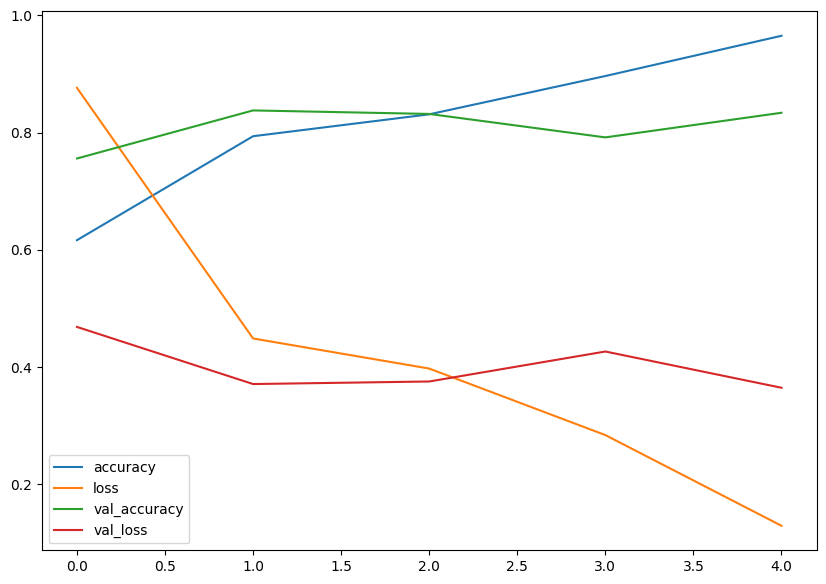

In [ ]:
# let's plot the training curves
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize =(10, 7));

In [ ]:
# PLot the validation and training curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history["loss"]   # for training data
  val_loss = history.history["val_loss"]  # for test data

  accuracy = history.history["accuracy"]   # for training data
  val_accuracy = history.history["val_accuracy"] # for test data

  epochs = range(len(history.history["loss"]))   # how many epochs did we run for , this should be the same for val_loss as weell

  # plot loss
  plt.plot(epochs , loss ,label ="training_loss")
  plt.plot(epochs , val_loss ,label ="val_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend();


  # plot accuracy
  plt.figure()
  plt.plot(epochs , accuracy , label="training_accuracy")
  plt.plot(epochs, val_accuracy , label ="val_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend();


**NOTE:** When a model's **validation loss starts to increase** , its likely that the model is **overfitting** the training dataset.

This means , it's learning the patterns in the training dataset too well and thus the model's ability to generalize to unseen data will be diminished.


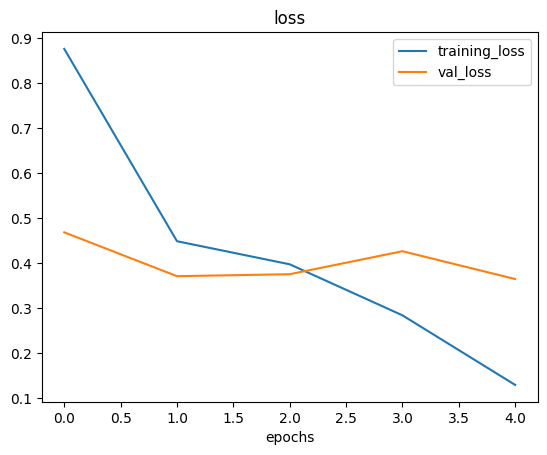

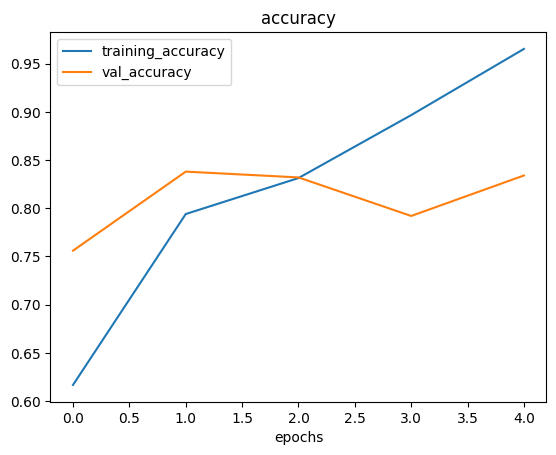

In [ ]:
# Check out the loss and accuracy of model_4
plot_loss_curves(history_4)

## Reducing Overfitting

Ideally the two loss curves (training and validation) will be very similar to each other decreasing at similar rates, when there are large differences your model may be overfitting.


### 6. Adjust the model parameters

Fitting machine learning model comes in steps:

0. Create a baseline
1. Beat the baseline by overfitting a larger model
2. Reduce overfitting


Ways to induce overfitting:

* Increase the number of Conv layers
* Increase the number of Concv filters
* Add another dense layer to output of our flattened layer

Ways to reduce overfitting:
 * Add data augmentation
 * Add regularization layers(Such as MaxPool2D)
 * Add more data...
 * Better data
 * Use transfer learning

 > Reducing Overfitting is also known as **Regularization**

In [ ]:
# create the model ( this is going to be our new baseline)
model_5 = Sequential([
    Conv2D(10, 3, activation= "relu" , input_shape =(224, 224 , 3)),
    MaxPool2D(pool_size = 2),
    Conv2D(10, 3, activation= "relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation= "relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation ="sigmoid")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model_5.compile(loss ="binary_crossentropy",
                optimizer= Adam(),
                metrics=["accuracy"])

In [ ]:
# Fit the model
history_5 = model_5.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = test_data,
                        validation_steps= len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.6118 - loss: 0.6416 - val_accuracy: 0.7900 - val_loss: 0.4529
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.7978 - loss: 0.4548 - val_accuracy: 0.7920 - val_loss: 0.4224
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.7761 - loss: 0.4672 - val_accuracy: 0.8300 - val_loss: 0.3830
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.7965 - loss: 0.4250 - val_accuracy: 0.8700 - val_loss: 0.3415
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.8284 - loss: 0.4011 - val_accuracy: 0.8660 - val_loss: 0.3491


In [ ]:
# Get a summary of our model with max pooling
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

In [ ]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)

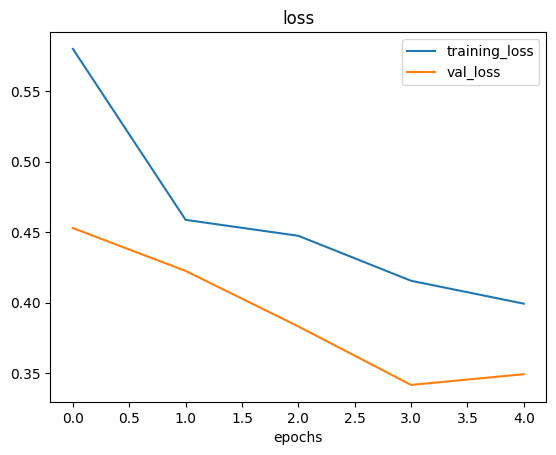

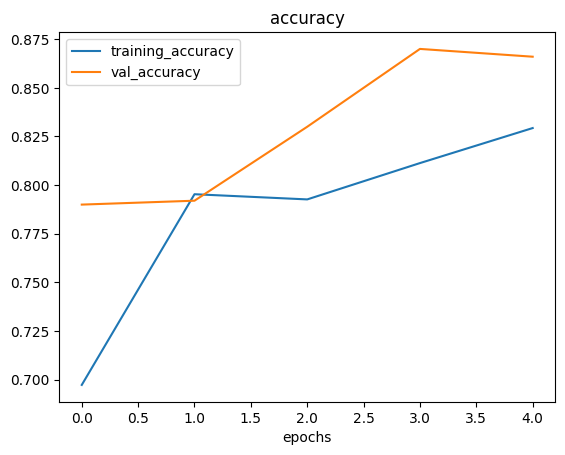

In [ ]:
plot_loss_curves(history_5)

After MaxPooling you can see that there is increase in accuracy and decrease in loss

### Opening our bag of tricks and finding data augmentation

In [ ]:
# Create ImageDataGenerator training instance
train_datagen_augmented = ImageDataGenerator(rescale =1/255.,
                                             rotation_range =0.2, # how much do you want to rotate an image?
                                             shear_range = 0.2, # how much do you want to shear an image
                                             zoom_range= 0.2,  #zoom in random  on an image
                                             width_shift_range= 0.2, # move your image around on the x-axis
                                             height_shift_range= 0.3,  # move your image around y axis
                                             horizontal_flip = True) # do you want to flip image

# Create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale = 1/255.)

# Create ImageDataGenerator without data augmentation for test data set
test_datagen = ImageDataGenerator(rescale =1/255.)

**What is data agumentation?**
Data augmentation is process of altering our taring data, leading it to have more diversity and in turn allowing our models to learn more generalizable (hopefully) patterns. Altering might mean adjusting the rotation of an image , flipping it, cropping it or something similar

lets write some code to visualize data augmentation..

In [ ]:
# Import data and augment it from training directory
print("Augmented training data")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size= (224, 224),
                                                                   batch_size= 32,
                                                                   class_mode ="binary",
                                                                   shuffle= False)
# the above is for demonstration purposes only
# Create non-augmented train data batches
print("Non-augmented Training data:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size= 32,
                                               class_mode ="binary",
                                               shuffle = False)

# Create non-augmented test data batches
print("Non-augmented test data:")
test_data= test_datagen.flow_from_directory(test_dir,
                                            target_size =(224, 224),
                                            batch_size =32,
                                            class_mode= "binary")


Augmented training data
Found 1500 images belonging to 2 classes.
Non-augmented Training data:
Found 1500 images belonging to 2 classes.
Non-augmented test data:
Found 500 images belonging to 2 classes.


Data augmentation usually only performed on the training data using ImageDataGenerator built-in data augmentation parameters our images are left as they are in directories but are modified as they're loaded into the model.

Finally .. lets visualize some augmented data!!

In [ ]:
# Get one batch of images and labels
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented)  # Labels aren't augmented, only images


Showing image number: 7


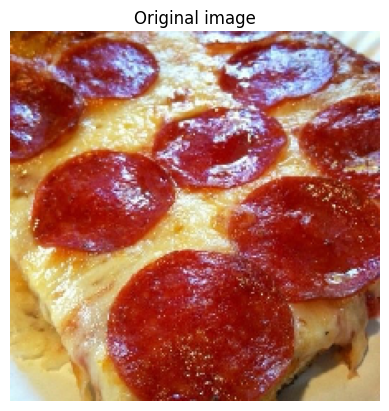

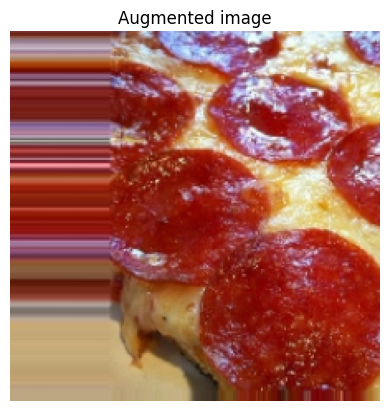

In [ ]:
# show the original image and augmented image
import random
random_number = random.randint(0 , 32)  # our batch sizes are 32
print(f"Showing image number: {random_number}")
plt.imshow(images[random_number])
plt.title(f"Original image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False);

Now we've seen that augmented training looks like , lets build a model and see how it learns on augmented data

In [ ]:
# Import data and augment  from training directory
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size =(224, 224),
                                                                            class_mode= "binary",
                                                                            batch_size = 32)


Found 1500 images belonging to 2 classes.


In [ ]:
# Create a model(same as model_5)
model_6 = Sequential([
    Conv2D(10, 3 , activation ="relu"),
    MaxPool2D(pool_size =2),
    Conv2D(10 , 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation = "relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation ="sigmoid")
])

# Compile the model
model_6.compile(loss ="binary_crossentropy",
                optimizer = Adam(),
                metrics= ["accuracy"])

# Fit the model
history_6 = model_6.fit( train_data_augmented,
                        epochs =5,
                        steps_per_epoch =len(train_data_augmented),
                        validation_data = test_data ,
                        validation_steps = len(test_data))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 438ms/step - accuracy: 0.5211 - loss: 0.6983 - val_accuracy: 0.6940 - val_loss: 0.5757
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 441ms/step - accuracy: 0.6625 - loss: 0.5998 - val_accuracy: 0.8260 - val_loss: 0.4238
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step - accuracy: 0.7393 - loss: 0.5322 - val_accuracy: 0.8000 - val_loss: 0.4043
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 435ms/step - accuracy: 0.7518 - loss: 0.4935 - val_accuracy: 0.8440 - val_loss: 0.3889
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 446ms/step - accuracy: 0.7561 - loss: 0.5114 - val_accuracy: 0.8160 - val_loss: 0.4272


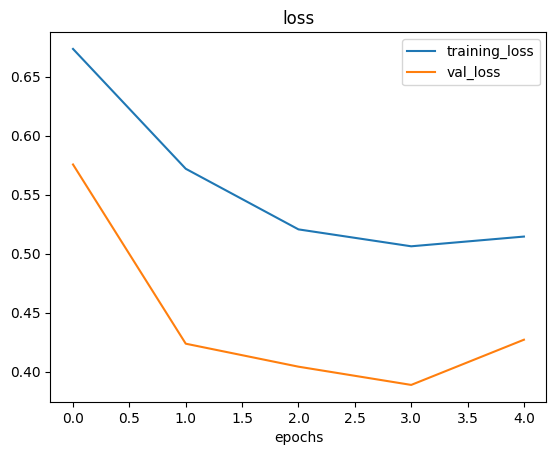

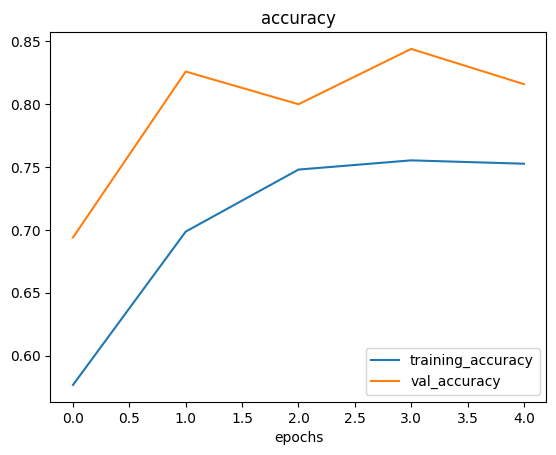

In [ ]:
# Check our models training curves
plot_loss_curves(history_6)

Let's shuffle our augmented training data and train another model(the same as before) on it and see what happens

In [ ]:
# Import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size =(224, 224),
                                                                            class_mode= "binary",
                                                                            batch_size = 32,
                                                                            shuffle =True)  # shuffle this time

Found 1500 images belonging to 2 classes.


In [ ]:
# Create the model (same as model_5 and model_6)
model_7 =Sequential([
    Conv2D(10, 3 , activation ="relu"),
    MaxPool2D(pool_size =2),
    Conv2D(10, 3, activation ="relu"),
    MaxPool2D(),
    Conv2D(10, 3 , activation ="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation = "sigmoid")
])

# Copile the model
model_7.compile(loss ="binary_crossentropy",
                optimizer = Adam(),
                metrics =["accuracy"])

# Fit the model
history_7 = model_7.fit(train_data_augmented_shuffled,
                        epochs =5 ,
                        steps_per_epoch = len(train_data_augmented_shuffled),
                        validation_data = test_data,
                        validation_steps = len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 453ms/step - accuracy: 0.5269 - loss: 0.6914 - val_accuracy: 0.5800 - val_loss: 0.6601
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 420ms/step - accuracy: 0.6553 - loss: 0.6173 - val_accuracy: 0.7780 - val_loss: 0.4586
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 431ms/step - accuracy: 0.7308 - loss: 0.5315 - val_accuracy: 0.8180 - val_loss: 0.4226
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 431ms/step - accuracy: 0.7645 - loss: 0.5081 - val_accuracy: 0.8440 - val_loss: 0.3636
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 420ms/step - accuracy: 0.7901 - loss: 0.4580 - val_accuracy: 0.8520 - val_loss: 0.3641


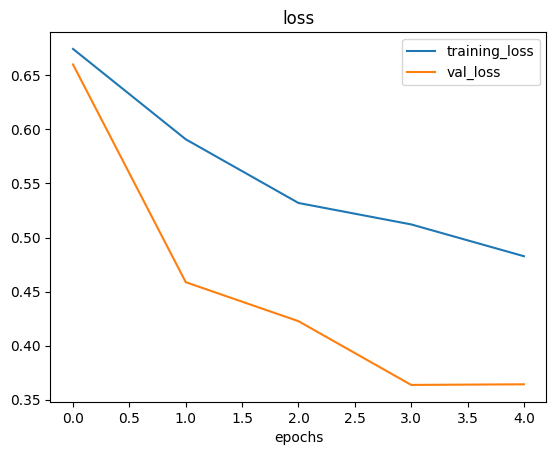

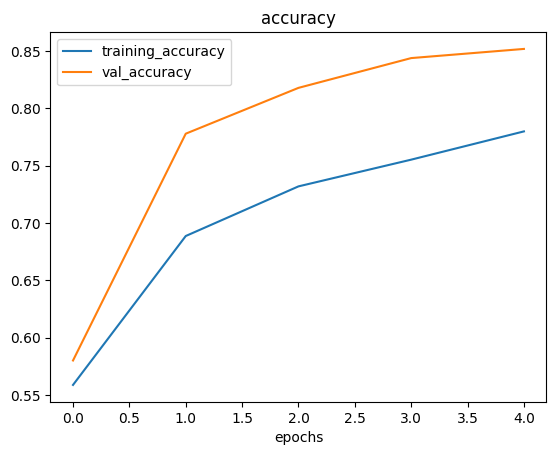

In [ ]:
# plot loss curves
plot_loss_curves(history_7)

When shuffling training data , the model gets exposed to all different kinds of data during training , thus enabling it to learn features across a wide array of images ( in our case , pizza and steak at the same time instead of just pizza then steak)

### 7. Repeat until satisfied
  Since , we've already beaten our baseline , there are few things we could try to continue to improve our model:

  * IN=ncrea the number of model layers(e.g add more `Conv2D`/ `MaxPool2D` layers)

  * Increase the number of filters in each convolutional layer
  (e.g from 10 to 32 or even 64)

  * Train for longer(more epochs)

  * Find an ideal learning rate

  * Get more data (give the model more oppurtunities to learn)

  * Use **Transfer Learning** to leverage what another image model has learn and adjust it for our own use case


## Making a prediction with our trainned model on our own custom data

In [ ]:
# Class'es we're working with
print(class_names)

['pizza' 'steak']


--2025-07-18 18:05:58--  https://github.com/mrdbourke/tensorflow-deep-learning/raw/main/images/03-steak.jpeg
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg [following]
--2025-07-18 18:05:59--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.008s  

2025-07-18 18:05:59 (225 MB/s) - ‘03-steak.jpeg’ saved [1978213

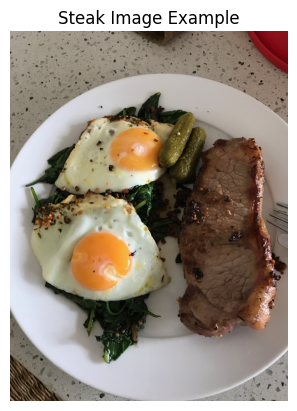

In [ ]:
# Import necessary libraries
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Download the image
!wget https://github.com/mrdbourke/tensorflow-deep-learning/raw/main/images/03-steak.jpeg -O 03-steak.jpeg

# Read the image using mpimg
steak = mpimg.imread("03-steak.jpeg")

# Display the image
plt.imshow(steak)
plt.axis("off")  # Use a string "off" instead of False
plt.title("Steak Image Example")
plt.show()


In [ ]:
steak.shape


(4032, 3024, 3)

> when you train a nueral network and you want to make a prediction with it on your own custom data , its important than your custom data(or new data) is preprocessed into same format as the data your model was trained on.

#  Create a function to import an image and resize it to able to be used with our model

In [ ]:
def load_and_prep_image(filename , img_shape =224):
  """
  reads an image from filename , turns it into a tensor and reshapes it to(imag_shape, immg_shape, colour_channel.

  """

  # Read in the image
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor
  img = tf.image.decode_image(img)

  # Resize the image
  img = tf.image.resize(img , size=[img_shape, img_shape])

  # rescale the image
  img =img/255.
  return img

In [ ]:
# what does pixel value look like
steak

array([[[162, 158, 149],
        [163, 159, 150],
        [166, 162, 153],
        ...,
        [136,  17,  23],
        [140,  21,  27],
        [140,  21,  27]],

       [[164, 160, 151],
        [164, 160, 151],
        [164, 160, 151],
        ...,
        [133,  14,  20],
        [134,  15,  21],
        [137,  18,  24]],

       [[166, 162, 153],
        [165, 161, 152],
        [163, 159, 150],
        ...,
        [136,  17,  23],
        [134,  15,  21],
        [136,  17,  23]],

       ...,

       [[154, 132, 111],
        [142, 121, 100],
        [101,  80,  59],
        ...,
        [164, 155, 148],
        [152, 141, 135],
        [140, 129, 123]],

       [[141, 119,  96],
        [138, 118,  94],
        [106,  85,  64],
        ...,
        [158, 147, 141],
        [142, 131, 125],
        [138, 127, 121]],

       [[148, 126, 102],
        [148, 128, 103],
        [114,  93,  72],
        ...,
        [153, 142, 136],
        [138, 127, 121],
        [143, 132, 126]]

In [ ]:
# load in and preprocess our custom image
steak = load_and_prep_image("03-steak.jpeg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [ ]:
 expanded_steak = tf.expand_dims(steak, axis= 0)

In [ ]:
pred = model_7.predict(expanded_steak)
pred

# it is the prediction probability, it belongs to one class or other

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step


array([[0.8953369]], dtype=float32)

Looks like our custom image is being put through our model, however , it currently outputs a prediction probability , wouldnt it be nice we could visualize the image as well as the model's prediction?



In [ ]:
# Remind ourselves of our class names
print(class_names)

['pizza' 'steak']


In [ ]:
# we cam index the  predicted class by rounding the prediction probability  and indexing it on the class names
pred_class = class_names[int(tf.round(pred))]
pred_class

np.str_('steak')

In [ ]:
def pred_and_plot(model , filename , class_names = class_names):
  """
  Imports an image located at filename , makes a prediction with model
  and plots the image with the predicted class ast the title.

  """
  # import the target image and [preprocess it
  img = load_and_prep_image(filename)

  # Mkae a prediction
  pred = model.predict(tf.expand_dims(img, axis =0))

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred))]

  # plot the image and predicted class
  plt.imshow(img)
  plt.title(f"prediction: {pred_class}")
  plt.axis(False);


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


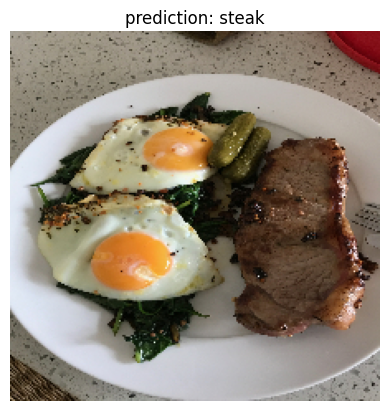

In [ ]:
# Test our model  on a custom image
pred_and_plot(model_7 , "03-steak.jpeg")

Our model works! Lets try it on another image.. this time


--2025-07-18 18:06:01--  https://github.com/mrdbourke/tensorflow-deep-learning/raw/main/images/03-pizza-dad.jpeg
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg [following]
--2025-07-18 18:06:02--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg’

03-pizza-dad.jpeg   100%[===================>]   2.74M  --.-KB/s    in 0.009s  

2025-07-18 18:06:02 (299 MB/s) - ‘03-pizza-dad.

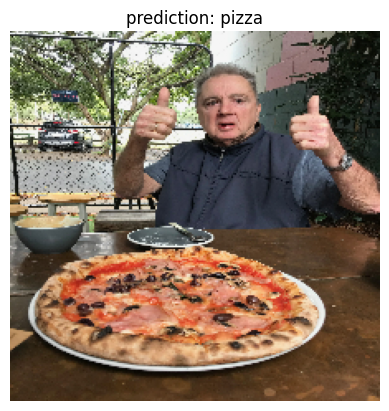

In [ ]:
# Download the image
!wget https://github.com/mrdbourke/tensorflow-deep-learning/raw/main/images/03-pizza-dad.jpeg

# Run prediction and plot the image
pred_and_plot(model_7, "03-pizza-dad.jpeg")
